In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

In [2]:
#dataset given in the mail
dataset = pd.read_csv('Information (2).csv', encoding = 'latin-1')

In [3]:
dataset.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,profileimage,retweet_count,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,...,https://pbs.twimg.com/profile_images/414342229...,0,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,...,https://pbs.twimg.com/profile_images/539604221...,0,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada)
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,...,https://pbs.twimg.com/profile_images/657330418...,1,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0000,yes,1.0,6/11/09 22:39,...,https://pbs.twimg.com/profile_images/259703936...,0,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada)
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0000,yes,1.0,4/16/14 13:23,...,https://pbs.twimg.com/profile_images/564094871...,0,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN


In [4]:
dataset['gender'].unique()

array(['male', 'female', 'brand', 'unknown', nan], dtype=object)

In [5]:
dataset.shape

(20050, 26)

In [6]:
for x in dataset.columns:
    print(x, dataset[x].isnull().sum())

_unit_id 0
_golden 0
_unit_state 0
_trusted_judgments 0
_last_judgment_at 50
gender 97
gender:confidence 26
profile_yn 0
profile_yn:confidence 0
created 0
description 3744
fav_number 0
gender_gold 20000
link_color 0
name 0
profile_yn_gold 20000
profileimage 0
retweet_count 0
sidebar_color 0
text 0
tweet_coord 19891
tweet_count 0
tweet_created 0
tweet_id 0
tweet_location 7485
user_timezone 7798


## Feature Selection

In [8]:
dataset.drop(['_unit_id', 'created', 'name', 'profileimage', 'gender_gold', 'profile_yn_gold',
             'user_timezone', 'tweet_location', 'tweet_id', '_last_judgment_at', 'fav_number',
             'tweet_coord', '_golden', '_unit_state', '_trusted_judgments', 'profile_yn',
             'profile_yn:confidence', 'gender_gold', 'link_color', 'profile_yn_gold',
             'sidebar_color', 'tweet_created'], axis = 1, inplace = True)

In [9]:
dataset.dropna(inplace = True)

In [10]:
dataset.shape

(16224, 6)

## Data Visualisation

Text(0.5, 1.0, 'Number of Records for each Category')

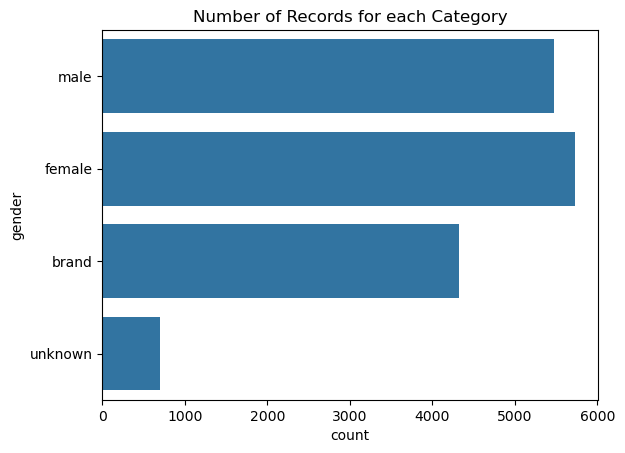

In [12]:
#plot of number of records for each category
sns.countplot(dataset['gender'],label="Gender")
plt.title('Number of Records for each Category')

In [ ]:
#dataset = dataset[dataset['gender'] != 'unknown']

Text(0.5, 1.0, 'Tweet Counts for each Category')

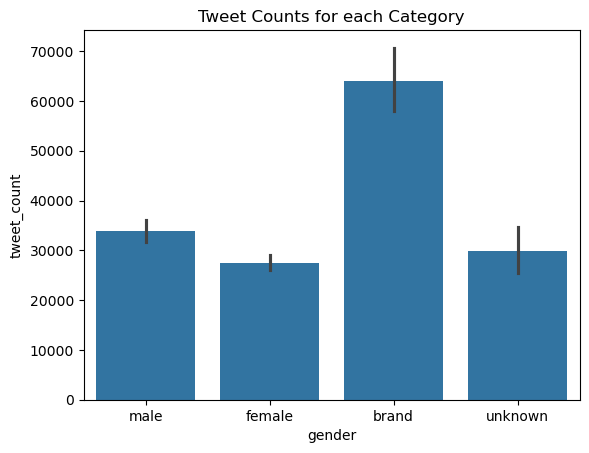

In [13]:
#number of tweets according to the categories
sns.barplot(x = 'gender', y = 'tweet_count', data = dataset)
plt.title('Tweet Counts for each Category')

Text(0.5, 1.0, 'Re-tweet count for each Category')

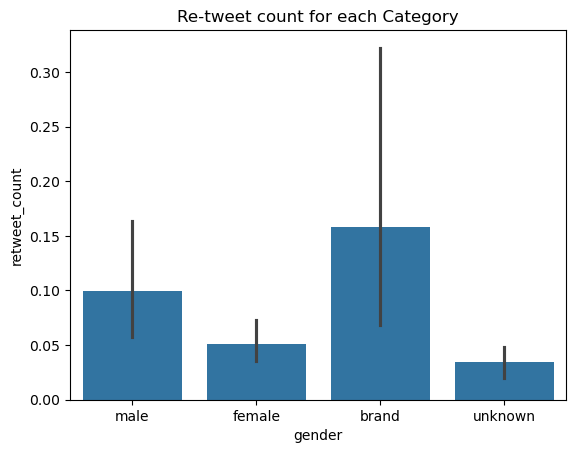

In [14]:
#number of re-tweets according to categories
sns.barplot(x = 'gender', y = 'retweet_count', data = dataset)
plt.title('Re-tweet count for each Category')

## Tags and Hyperlinks

In [16]:
males_df = dataset[dataset['gender'] == 'male']
females_df = dataset[dataset['gender'] == 'female']
brands_df = dataset[dataset['gender'] == 'brand']
unknown_df = dataset[dataset['gender'] == 'unknown']

In [17]:
male_tags_count, females_tags_count, brands_tags_count, unknown_tags_count = 0, 0, 0, 0
for x in males_df['text']:
    if '#' in x:
        male_tags_count += x.count('#')
for x in females_df['text']:
    if '#' in x:
        females_tags_count += x.count('#')
for x in brands_df['text']:
    if '#' in x:
        brands_tags_count += x.count('#')
for x in unknown_df['text']:
    if '#' in x:
        unknown_tags_count += x.count('#')

In [18]:
gender_tags = {'male': male_tags_count, 'female': females_tags_count, 'brand': brands_tags_count, 'unknown': unknown_tags_count}
keys = gender_tags.keys()
values = gender_tags.values()

Text(0.5, 1.0, 'Number of Tags used by each Category')

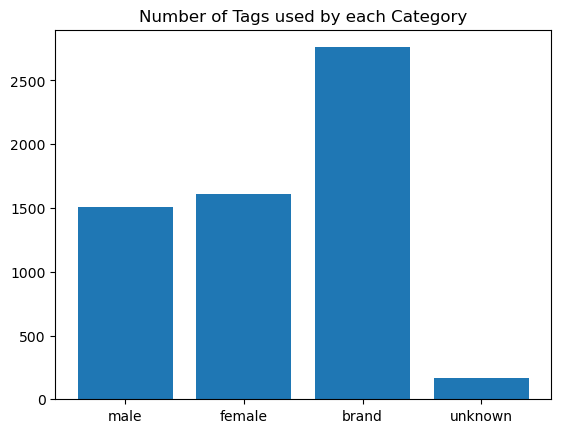

In [19]:
#plot of category vs no.of tags used
plt.bar(keys, values)
plt.title('Number of Tags used by each Category')

## Removing all Punctuations along with hyperlinks, tags, @names

In [21]:
def cleaning(s):
    not_req = ['@', '#', '://']
    s = str(s)
    s = s.lower()
    s = re.sub("\d+", "", s)
    s = re.sub(r'\\d+', '', s)
    s = re.sub(r'http\\S+|www\\.\\S+', '', s)
    s = re.sub(r'[^\\w\\s]', '', s)
    lst = s.split(' ')
    lst1 = []
    for x in lst:
        for el in not_req:
            if el in x:
                lst1.append(x)
    for i in lst1:
        try:
            lst.remove(i)
        except ValueError:
            pass
    final_str = " ".join(lst)
    final_str = re.sub(r'[^\w\s]', '', final_str)

    return final_str

In [22]:
dataset['text'] = [cleaning(x) for x in dataset['text']]
dataset['description'] = [cleaning(x) for x in dataset['description']]

In [23]:
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617
3,male,1.0000,mobile guy ers shazam google kleiner perkins ...,0,hi looking at the url do you use dont typic...,1693
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462


## Natural Language Processing

In [25]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   

True

In [26]:
from nltk.corpus import stopwords

In [27]:
from nltk.corpus import stopwords

In [28]:
list_of_stopwords = stopwords.words('English')

In [30]:
#function for tokenizing the words
def tokenization(text):
    text = re.split('\W+', text)
    return text

dataset['Text_tokenized'] = dataset['text'].apply(lambda x: tokenization(x.lower()))
dataset['descp_tokenized'] = dataset['description'].apply(lambda x: tokenization(x.lower()))

In [31]:
#function for removing stopwords
def remove_stopwords(text):
    text = [word for word in text if word not in list_of_stopwords]
    return text
    
dataset['Text_nonstop'] = dataset['Text_tokenized'].apply(lambda x: remove_stopwords(x))
dataset['desc_nonstop'] = dataset['descp_tokenized'].apply(lambda x: remove_stopwords(x))
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count,Text_tokenized,descp_tokenized,Text_nonstop,desc_nonstop
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964,"[robbie, e, responds, to, critics, after, win,...","[i, sing, my, own, rhythm]","[robbie, e, responds, critics, win, eddie, edw...","[sing, rhythm]"
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471,"[ûïit, felt, like, they, were, my, friends, an...","[im, the, author, of, novels, filled, with, fa...","[ûïit, felt, like, friends, living, story, themû]","[im, author, novels, filled, family, drama, ro..."
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617,"[i, absolutely, adore, when, louis, starts, th...","[louis, whining, and, squealing, and, all]","[absolutely, adore, louis, starts, songs, hits...","[louis, whining, squealing]"
3,male,1.0000,mobile guy ers shazam google kleiner perkins ...,0,hi looking at the url do you use dont typic...,1693,"[hi, looking, at, the, url, do, you, use, dont...","[mobile, guy, ers, shazam, google, kleiner, pe...","[hi, looking, url, use, dont, typically, see, ...","[mobile, guy, ers, shazam, google, kleiner, pe..."
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462,"[watching, neighbours, on, sky, catching, up, ...","[ricky, wilson, the, best, frontmankaiser, chi...","[watching, neighbours, sky, catching, neighbs,...","[ricky, wilson, best, frontmankaiser, chiefs, ..."


In [32]:
ps = nltk.PorterStemmer()

def stemming(text):
    text = [ps.stem(word) for word in text]
    return text

dataset['Text_stemmed'] = dataset['Text_nonstop'].apply(lambda x: stemming(x))
dataset['descp_stemmed'] = dataset['desc_nonstop'].apply(lambda x: stemming(x))
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count,Text_tokenized,descp_tokenized,Text_nonstop,desc_nonstop,Text_stemmed,descp_stemmed
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964,"[robbie, e, responds, to, critics, after, win,...","[i, sing, my, own, rhythm]","[robbie, e, responds, critics, win, eddie, edw...","[sing, rhythm]","[robbi, e, respond, critic, win, eddi, edward]","[sing, rhythm]"
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471,"[ûïit, felt, like, they, were, my, friends, an...","[im, the, author, of, novels, filled, with, fa...","[ûïit, felt, like, friends, living, story, themû]","[im, author, novels, filled, family, drama, ro...","[ûïit, felt, like, friend, live, stori, themû]","[im, author, novel, fill, famili, drama, romanc]"
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617,"[i, absolutely, adore, when, louis, starts, th...","[louis, whining, and, squealing, and, all]","[absolutely, adore, louis, starts, songs, hits...","[louis, whining, squealing]","[absolut, ador, loui, start, song, hit, hard, ...","[loui, whine, squeal]"
3,male,1.0000,mobile guy ers shazam google kleiner perkins ...,0,hi looking at the url do you use dont typic...,1693,"[hi, looking, at, the, url, do, you, use, dont...","[mobile, guy, ers, shazam, google, kleiner, pe...","[hi, looking, url, use, dont, typically, see, ...","[mobile, guy, ers, shazam, google, kleiner, pe...","[hi, look, url, use, dont, typic, see, advanc,...","[mobil, guy, er, shazam, googl, kleiner, perki..."
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462,"[watching, neighbours, on, sky, catching, up, ...","[ricky, wilson, the, best, frontmankaiser, chi...","[watching, neighbours, sky, catching, neighbs,...","[ricky, wilson, best, frontmankaiser, chiefs, ...","[watch, neighbour, sky, catch, neighb, xxx, _ù...","[ricki, wilson, best, frontmankais, chief, bes..."


In [33]:
#combining all the words for creating the bag of words
dataset['list_of_all_words'] = dataset['Text_stemmed'] + dataset['descp_stemmed']

In [34]:
#joining the words to sentences
dataset['final_sentences'] = [' '.join(x) for x in dataset['list_of_all_words']]

### Maximum Used Words according to the Categories

In [36]:
male_dataset = dataset[dataset['gender'] == 'male']
female_dataset = dataset[dataset['gender'] == 'female']
brand_dataset = dataset[dataset['gender'] == 'brand']
unknown_dataset = dataset[dataset['gender'] == 'unknown']

In [37]:
male_words = ' '.join(male_dataset['final_sentences'])
male_words_count = pd.Series(male_words.split(" ")).value_counts()[:30]
female_words = ' '.join(female_dataset['final_sentences'])
female_words_count = pd.Series(female_words.split(" ")).value_counts()[:30]
brand_words = ' '.join(brand_dataset['final_sentences'])
brand_words_count = pd.Series(brand_words.split(" ")).value_counts()[:30]
unknown_words = ' '.join(unknown_dataset['final_sentences'])
unknown_words_count = pd.Series(unknown_words.split(" ")).value_counts()[:30]

In [38]:
male_words_count.drop(labels = '', inplace = True)
female_words_count.drop(labels = '', inplace = True)
brand_words_count.drop(labels = '', inplace = True)
unknown_words_count.drop(labels = '', inplace = True)

#### Female

<Axes: >

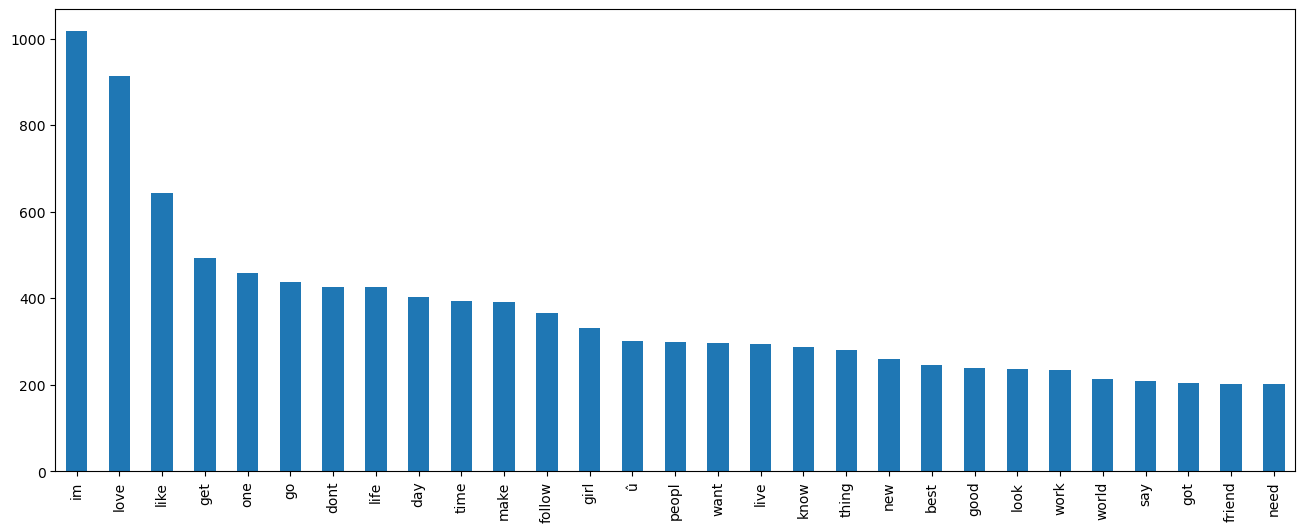

In [40]:
plt.figure(figsize = (16, 6))
female_words_count.plot(kind='bar',stacked=True)

#### Male

<Axes: >

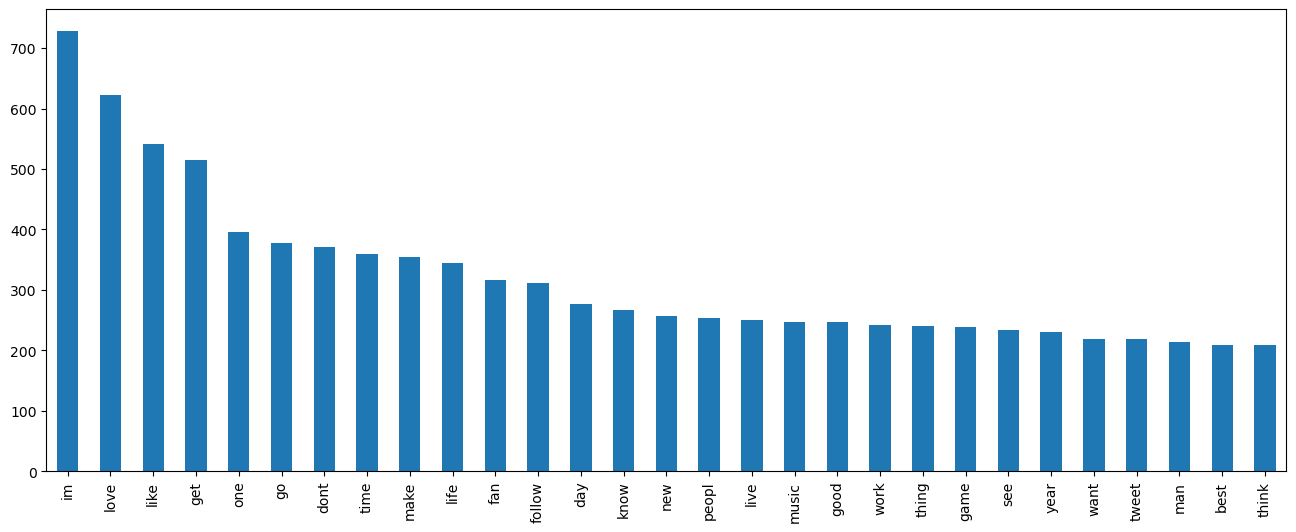

In [42]:
plt.figure(figsize = (16, 6))
male_words_count.plot(kind='bar',stacked=True)

#### Brand

<Axes: >

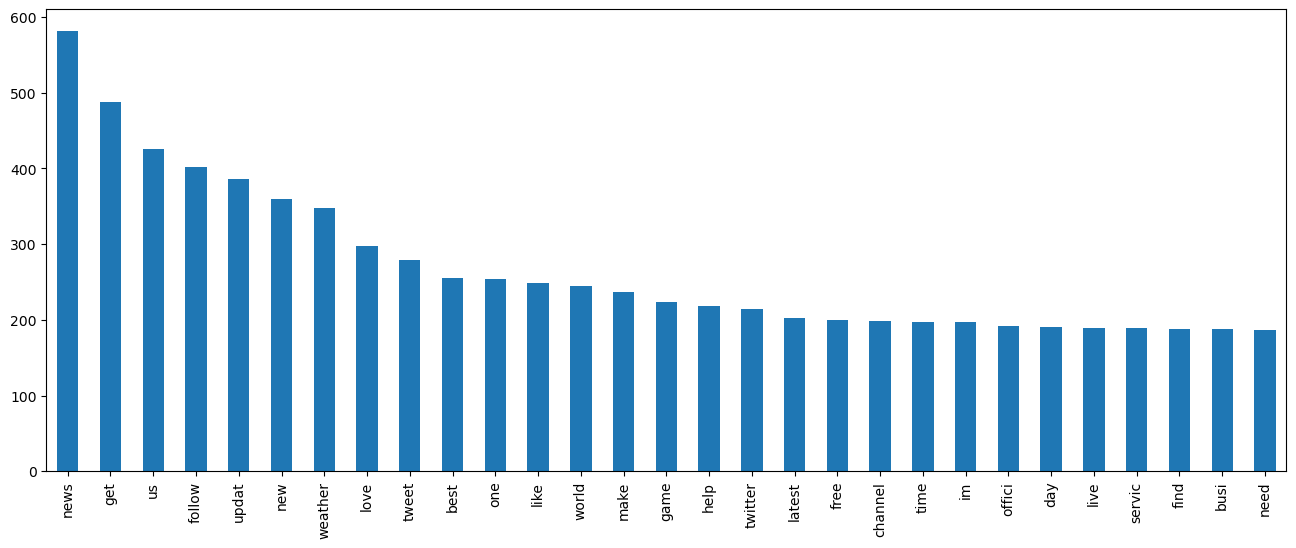

In [44]:
plt.figure(figsize = (16, 6))
brand_words_count.plot(kind='bar',stacked=True)

#### Unknown

<Axes: >

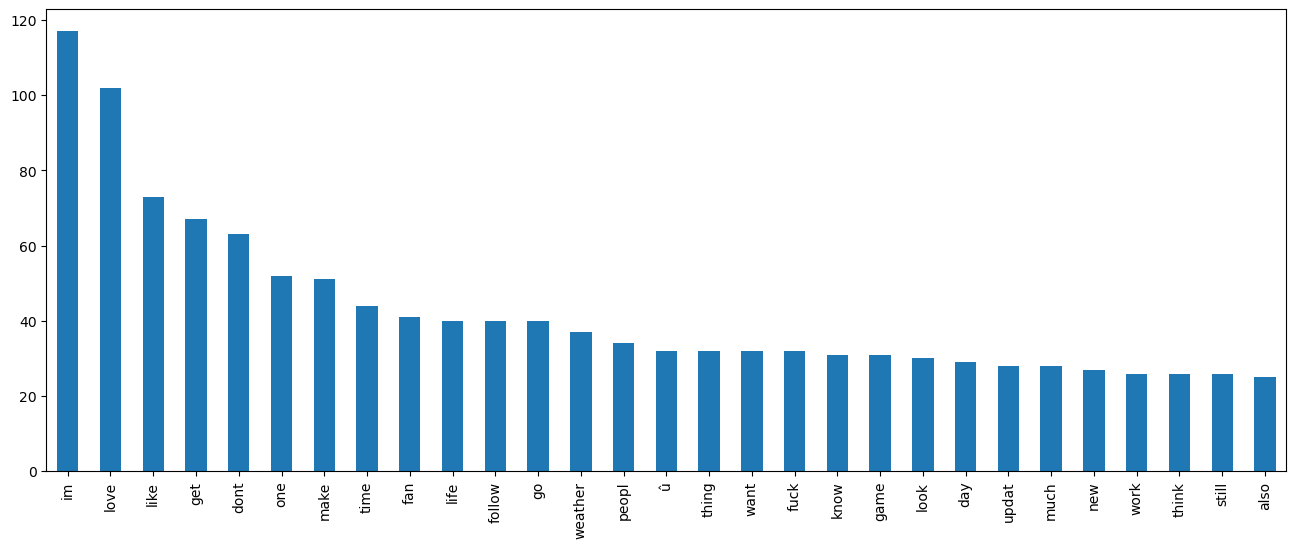

In [46]:
plt.figure(figsize = (16, 6))
unknown_words_count.plot(kind='bar',stacked=True)

## Bag of Words

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
cv = CountVectorizer(max_features = 9000)
X1 = cv.fit_transform(dataset['final_sentences']).toarray()

In [50]:
X1.shape

(16224, 9000)

## Array for Independent and Dependent Variables

In [52]:
# making a numpy array for gender confidence, tweet_count and retweet_count
X2 = dataset.iloc[:, [1, 3, 5]].values

In [53]:
# concatenating both numpy arrays to make the final data omn independent variables
X = np.concatenate((X1, X2), axis = 1)

In [54]:
X.shape

(16224, 9003)

In [55]:
#converting string variables to numbers using LabelEncoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['gender'] = le.fit_transform(dataset['gender'])

In [56]:
#Numpy array for Dependent Variable
y = dataset.iloc[:, 0].values

## Splitting dataset to Training and Testing

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Classification

## Gaussian NB

In [61]:
from sklearn.naive_bayes import GaussianNB

In [62]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [63]:
y_pred_gnb = gnb.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
print("Gaussian NB: ", accuracy_score(y_pred_gnb, y_test )*100)

Gaussian NB:  37.26376335250616


## RandomForest Classifier

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rfc = RandomForestClassifier(n_estimators=50, random_state = 0)
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=0)

In [69]:
y_pred_rfc = rfc.predict(X_test)

In [70]:
print("Random Forest: ", accuracy_score(y_pred_rfc, y_test )*100)

Random Forest:  55.95727198027938


## XGBoost

In [72]:
from xgboost import XGBClassifier

In [73]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print("XGBoost", accuracy_score(y_pred_xgb, y_test )*100)